# Introduction to Colab, Python, and ASE

This notebook is an introduction to computational molecular simulation using Python in Google Colab. **It is designed for people with little or no prior experience in scientific computing**, and walks through the full stack from basic shell commands to running quantum mechanical calculations.

This notebook is going to teach:

1. The Google Colab environment and core Python skills: running shell commands, manipulating files, working with variables and functions, and handling tabular data with pandas and numpy.

2. The Atomic Simulation Environment (ASE), a Python library for building, visualizing, and manipulating molecular structures, fetching molecules from public databases like PubChem and generating arbitrary geometries from SMILES strings.

3. To use TBLite (a fast semiempirical quantum chemistry engine) as a calculator within ASE to run real simulations: geometry optimizations, constrained potential energy surface scans, and normal mode analysis.
By working through the examples, you will see how a computational chemistry workflow connects code, physical intuition, and numerical output. No prior knowledge of quantum chemistry is required, though familiarity with basic Python syntax will help.

**Setup & Core Utilities**
Install the necessary packages for the tutorial (`ase`, `rdkit2ase`, `tblite`) and import core libraries. The `%%capture` command is used to hide the lengthy installation output.



In [ ]:
######################################################
##-install the necessery packages for this tutorial-##
######################################################

%%capture
!pip install ase
!pip install rdkit2ase
!pip install tblite

In [ ]:
#########################
##-Importing libraries-##
#########################

##-Standard library
import math
from math import cos, pi, sin
from scipy.optimize import curve_fit

##-Data
import pandas as pd
import numpy as np

##-ASE - structure building
from ase import Atoms
from ase.build import molecule
from ase.collections import g2
from ase.data.pubchem import pubchem_atoms_search
from rdkit2ase import smiles2atoms

##-ASE - I/O and visualization
from ase.io import read, write
from ase.visualize import view

##-ASE - simulation
from ase.optimize import BFGS, QuasiNewton
from ase.constraints import FixInternals
from ase.vibrations import Vibrations

##-Calculator
from tblite.ase import TBLite

## Colab

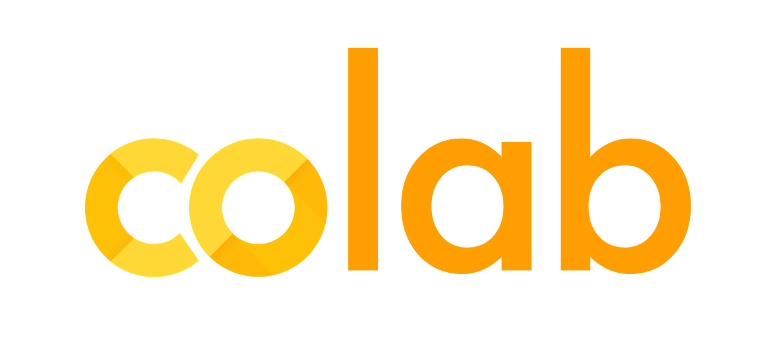

Google Colab is a cloud-based platform that allows to execute Python, Shell and other code, including core unilities.

In Google Colab, notebooks are composed of two primary types of cells: text cells and code cells (with a play-button).

*  Run your very first Python command by printing a welcome message to confirm the notebook is functioning.

In [ ]:
##-To run the following python-code cell press SHIFT+ENTER or click on the play-button on the right of this cell.
##-The print() function prints the specified message to the screen, or other standard output device.
print("Welcome to Colab!")

Welcome to Colab!


## Core utilities

Google Colab runs on a Linux backend. Use the exclamation mark (`!`) prefix to execute bash commands. Here, you will list files (`!ls`), create a new file (`!touch`), write text to it (`!echo`, `!printf`), view its contents (`!cat`), and create a new directory (`!mkdir`).

In [ ]:
##-List files and folders in the working directory.
!ls

sample_data


In [ ]:
##-Touch a test file. Opens a file to for it to be modified. As this file does not exist, the command will create the file.
!touch test_file.txt

In [ ]:
!ls

sample_data  test_file.txt


In [ ]:
##-To write some content to a file, use "echo" or "printf" (print formatted).
##-the > will write the output of the former command into the the file, while overwriting.
##- >> will append the output to the file, not overwriting.

!echo "First line" > test_file.txt
!printf "\nSecond line" >> test_file.txt

In [ ]:
##-To view the content of a file, use "cat" (concatenate).

!cat test_file.txt

First line

Second line

In [ ]:
##-To make a test directory, use "mkdir".

!mkdir test_directory

##-it will throw an error if the folder exist

 Use the `!wget` command to download external files from the web (a CSV file containing the Periodic Table) and use `!cat` to view the raw, unformatted data.


In [ ]:
##-To get an external file from the web, use "wget".

!wget https://gist.githubusercontent.com/GoodmanSciences/c2dd862cd38f21b0ad36b8f96b4bf1ee/raw/1d92663004489a5b6926e944c1b3d9ec5c40900e/Periodic%2520Table%2520of%2520Elements.csv

--2026-06-14 09:39:14--  https://gist.githubusercontent.com/GoodmanSciences/c2dd862cd38f21b0ad36b8f96b4bf1ee/raw/1d92663004489a5b6926e944c1b3d9ec5c40900e/Periodic%2520Table%2520of%2520Elements.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14979 (15K) [text/plain]
Saving to: ‘Periodic Table of Elements.csv’

Periodic Table of E 100%[===================>]  14.63K  --.-KB/s    in 0s      

2026-06-14 09:39:14 (111 MB/s) - ‘Periodic Table of Elements.csv’ saved [14979/14979]



In [ ]:
!cat "Periodic Table of Elements.csv"

AtomicNumber,Element,Symbol,AtomicMass,NumberofNeutrons,NumberofProtons,NumberofElectrons,Period,Group,Phase,Radioactive,Natural,Metal,Nonmetal,Metalloid,Type,AtomicRadius,Electronegativity,FirstIonization,Density,MeltingPoint,BoilingPoint,NumberOfIsotopes,Discoverer,Year,SpecificHeat,NumberofShells,NumberofValence
1,Hydrogen,H,1.007,0,1,1,1,1,gas,,yes,,yes,,Nonmetal,0.79,2.2,13.5984,8.99E-05,14.175,20.28,3,Cavendish,1766,14.304,1,1
2,Helium,He,4.002,2,2,2,1,18,gas,,yes,,yes,,Noble Gas,0.49,,24.5874,1.79E-04,,4.22,5,Janssen,1868,5.193,1,
3,Lithium,Li,6.941,4,3,3,2,1,solid,,yes,yes,,,Alkali Metal,2.1,0.98,5.3917,5.34E-01,453.85,1615,5,Arfvedson,1817,3.582,2,1
4,Beryllium,Be,9.012,5,4,4,2,2,solid,,yes,yes,,,Alkaline Earth Metal,1.4,1.57,9.3227,1.85E+00,1560.15,2742,6,Vaulquelin,1798,1.825,2,2
5,Boron,B,10.811,6,5,5,2,13,solid,,yes,,,yes,Metalloid,1.2,2.04,8.298,2.34E+00,2573.15,4200,6,Gay-Lussac,1808,1.026,2,3
6,Carbon,C,12.011,6,6,6,2,14,solid,,yes,,yes,,Nonmetal,0.91,2.55,11.2603,2.27E

### **Python Basics**
Practice fundamental Python concepts. You will assign text to a variable, print it using f-string notation, define a function that saves a value (`return`), define a function that just prints an output, and use a `for` loop to iterate through a custom list.

### Printing text

In [ ]:
print("Hello")

Hello


### Setting variables

In [ ]:
variable = "ABC"

print(f"The stored variable is {variable}")

The stored variable is ABC


In [ ]:
print("The stored variable is "+variable)

The stored variable is ABC


### Defining fuctions

In [ ]:
##-Function with return
def custom_text(variable_text):
  text = f"The stored variable is {variable_text}"
  return text
print(custom_text("A"))

The stored variable is A


In [ ]:
##-Function with no return
def print_custom(variable_text):
  print(f"The stored variable is {variable_text}")
print_custom("B")

The stored variable is B


### Lists and loops

In [ ]:
##-initialize a list
items = ["A", "B", "C"]

##-print every list item
for item in items:
  print_custom(item)

The stored variable is A
The stored variable is B
The stored variable is C


 Use the `pandas` library to import your downloaded Periodic Table CSV. Pandas neatly formats the raw data into an easily readable DataFrame table (`pd.read_csv`). Then, run a scatter plot to visually analyze the correlation between the number of protons and atomic mass.


#### Using dataframes

In [ ]:
df = pd.read_csv("Periodic Table of Elements.csv")
df

,AtomicNumber,Element,Symbol,AtomicMass,NumberofNeutrons,NumberofProtons,NumberofElectrons,Period,Group,Phase,...,FirstIonization,Density,MeltingPoint,BoilingPoint,NumberOfIsotopes,Discoverer,Year,SpecificHeat,NumberofShells,NumberofValence
0,1,Hydrogen,H,1.007,0,1,1,1,1.0,gas,...,13.5984,0.000090,14.175,20.28,3.0,Cavendish,1766.0,14.304,1,1.0
1,2,Helium,He,4.002,2,2,2,1,18.0,gas,...,24.5874,0.000179,NaN,4.22,5.0,Janssen,1868.0,5.193,1,NaN
2,3,Lithium,Li,6.941,4,3,3,2,1.0,solid,...,5.3917,0.534000,453.850,1615.00,5.0,Arfvedson,1817.0,3.582,2,1.0
3,4,Beryllium,Be,9.012,5,4,4,2,2.0,solid,...,9.3227,1.850000,1560.150,2742.00,6.0,Vaulquelin,1798.0,1.825,2,2.0
4,5,Boron,B,10.811,6,5,5,2,13.0,solid,...,8.2980,2.340000,2573.150,4200.00,6.0,Gay-Lussac,1808.0,1.026,2,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,114,Flerovium,Fl,289.000,175,114,114,7,14.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,1999.0,NaN,7,4.0
114,115,Moscovium,Mc,288.000,173,115,115,7,15.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,2010.0,NaN,7,5.0
115,116,Livermorium,Lv,292.000,176,116,116,7,16.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,2000.0,NaN,7,6.0
116,117,Tennessine,Ts,295.000,178,117,117,7,17.0,artificial,...,NaN,NaN,NaN,NaN,NaN,NaN,2010.0,NaN,7,7.0


<Axes: xlabel='Number of Protons', ylabel='Atomic Mass'>

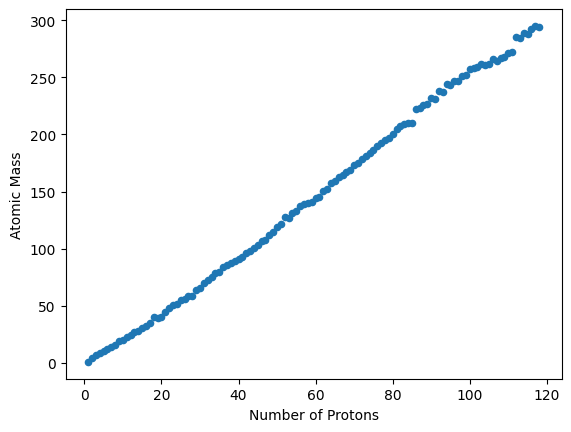

In [ ]:
df.plot.scatter(x='NumberofProtons', y='AtomicMass', xlabel='Number of Protons', ylabel='Atomic Mass')

Learn to create a DataFrame from scratch. You will generate a numerical array using `numpy.linspace`, apply a mathematical function to it (creating a parabola), place the values into a new DataFrame, visualize it with `.plot.scatter()`, and save your new table locally as a CSV file.


In [ ]:

##-create dummy array with values from 0 to 20
x_values = np.linspace(0, 20, 101)
y_values = x_values**2

##-create df
df = pd.DataFrame({"x": x_values, "y": y_values})
df

,x,y
0,0.0,0.00
1,0.2,0.04
2,0.4,0.16
3,0.6,0.36
4,0.8,0.64
...,...,...
96,19.2,368.64
97,19.4,376.36
98,19.6,384.16
99,19.8,392.04


<Axes: xlabel='x', ylabel='y'>

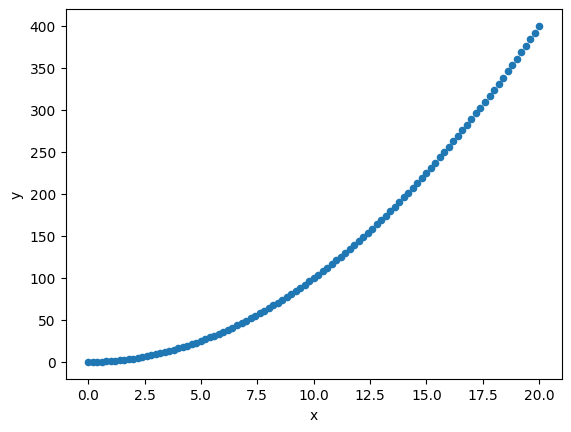

In [ ]:
df.plot.scatter(x='x', y='y')

In [ ]:
df.to_csv("test_1.csv")

## ASE

ASE or Atomic Simulation Enviroment is a Python module aimed to create, perform, and automate simulations.

For more details, documentation and tutorials:
https://wiki.fysik.dtu.dk/ase/about.html



Use ASE's `molecule` function to build a basic molecule (formic acid). You will visualize it in 3D using `view()`, save its atomic coordinates to an XYZ file using `write()`, and learn how to read it back into the program.


In [ ]:
atoms = molecule("HCOOH")
atoms

Atoms(symbols='OCOH2', pbc=False)

In [ ]:
view(atoms, viewer='x3d')

The atoms can be saved and read to file:

The xyz format is often the most simply human readable way to save the atomic system, but be aware there can be differences in format between different programs.

The usual format is; first line number of atoms, second line comments many programs will put system information here; subsequent lines are atoms with the type and cartesian coordinates.

In [ ]:
write("HCOOH.xyz", atoms)

In [ ]:
!cat HCOOH.xyz

5
Properties=species:S:1:pos:R:3 pbc="F F F"
O       -1.04094500      -0.43643200       0.00000000
C        0.00000000       0.42394900       0.00000000
O        1.16937200       0.10374100       0.00000000
H       -0.64957000      -1.33513400       0.00000000
H       -0.37784700       1.45296700       0.00000000


In [ ]:
atoms = read("HCOOH.xyz")
view(atoms, viewer='x3d')

There is collection of common molecules (g2) in the "collections" module.

In [ ]:
print(g2.names)

['PH3', 'P2', 'CH3CHO', 'H2COH', 'CS', 'OCHCHO', 'C3H9C', 'CH3COF', 'CH3CH2OCH3', 'HCOOH', 'HCCl3', 'HOCl', 'H2', 'SH2', 'C2H2', 'C4H4NH', 'CH3SCH3', 'SiH2_s3B1d', 'CH3SH', 'CH3CO', 'CO', 'ClF3', 'SiH4', 'C2H6CHOH', 'CH2NHCH2', 'isobutene', 'HCO', 'bicyclobutane', 'LiF', 'Si', 'C2H6', 'CN', 'ClNO', 'S', 'SiF4', 'H3CNH2', 'methylenecyclopropane', 'CH3CH2OH', 'F', 'NaCl', 'CH3Cl', 'CH3SiH3', 'AlF3', 'C2H3', 'ClF', 'PF3', 'PH2', 'CH3CN', 'cyclobutene', 'CH3ONO', 'SiH3', 'C3H6_D3h', 'CO2', 'NO', 'trans-butane', 'H2CCHCl', 'LiH', 'NH2', 'CH', 'CH2OCH2', 'C6H6', 'CH3CONH2', 'cyclobutane', 'H2CCHCN', 'butadiene', 'C', 'H2CO', 'CH3COOH', 'HCF3', 'CH3S', 'CS2', 'SiH2_s1A1d', 'C4H4S', 'N2H4', 'OH', 'CH3OCH3', 'C5H5N', 'H2O', 'HCl', 'CH2_s1A1d', 'CH3CH2SH', 'CH3NO2', 'Cl', 'Be', 'BCl3', 'C4H4O', 'Al', 'CH3O', 'CH3OH', 'C3H7Cl', 'isobutane', 'Na', 'CCl4', 'CH3CH2O', 'H2CCHF', 'C3H7', 'CH3', 'O3', 'P', 'C2H4', 'NCCN', 'S2', 'AlCl3', 'SiCl4', 'SiO', 'C3H4_D2d', 'H', 'COF2', '2-butyne', 'C2H5', 'BF3'

It is possible to import molecules from pubchem: https://pubchem.ncbi.nlm.nih.gov.

Call molecules from built-in historical databases (like the `g2` collection) or fetch real-world structures (like Vitamin A/Retinol) directly from PubChem via its CID or name.


In [ ]:
vitamin_A = pubchem_atoms_search(name="Retinol")
view(vitamin_A, viewer='x3d')

/usr/local/lib/python3.12/dist-packages/ase/data/pubchem.py:74: UserWarning: The structure "Retinol" has more than one conformer in PubChem. By default, the first conformer is returned, please ensure you are using the structure you intend to or use the `ase.data.pubchem.pubchem_conformer_search` function
  warnings.warn(


Generate complex molecular structures rapidly using SMILES strings (a text-based chemical notation) and RDKit, then visualize the generated geometry.

Arbitrary structures can be created using SMILES with RDKit.

You can draw and generate SMILES using MolView: https://molview.org.

In [ ]:
atoms = smiles2atoms('C1=CC2=C3C4=C1C=CC5=C4C6=C(C=C5)C=CC7=C6C3=C(C=C2)C=C7')
view(atoms, viewer='x3d')

In [ ]:
atoms = smiles2atoms('C(C1CC=CCO1)1=CC(Cl)=CC=C1I')
view(atoms, viewer='x3d')

## Simulations with ASE

ASE allows to use various codes as calculators to perform simulations. One of the cheapest one is TBLite: https://tblite.readthedocs.io/en/latest/users/ase.html.

 Define `TBLite` as your simulation calculator and set its parameters (like the `GFN1-xTB` method). Attach this calculator to an ammonia (NH3) molecule to run a "single point calculation" and extract its current potential energy.


In [ ]:
calc = TBLite(method="GFN1-xTB", max_iterations=500, accuracy=1, verbosity=0)

### Simulation of NH₃

To get energy of atoms object, run a single point calculation.

In [ ]:
atoms = molecule("NH3")
atoms.calc = calc
E = atoms.get_potential_energy()

In [ ]:
print(f"The energy of NH3 is {E:.2f} eV")

The energy of NH3 is -131.43 eV


Use the `BFGS` optimizer to find the most stable, lowest-energy geometry for NH3. The optimizer subtly shifts the atoms until the maximum force (`fmax`) acting on them drops below a target threshold.


In [ ]:
BFGS(atoms, trajectory="NH3.traj").run(fmax=0.01)

      Step     Time          Energy          fmax
BFGS:    0 09:39:17     -131.433339        0.625747
BFGS:    1 09:39:17     -131.439032        0.284293
BFGS:    2 09:39:17     -131.441299        0.144453
BFGS:    3 09:39:17     -131.442966        0.122433
BFGS:    4 09:39:17     -131.443686        0.043760
BFGS:    5 09:39:17     -131.443748        0.013033
BFGS:    6 09:39:17     -131.443752        0.001460


np.True_

In [ ]:
view(atoms, viewer='x3d')

 Define a custom mathematical function that manually builds an ammonia molecule using sine and cosine functions. Crucially, apply a `FixInternals` constraint so the specified angle gets "locked" and cannot snap back to equilibrium during optimization.


In [ ]:
def create_nh3_angle(angle: float) -> tuple[Atoms, float]:
  ##-Convert to radians
  angle = angle*math.pi/180

  ##-Create NH3 with custom angle
  N_H_dist = 1
  N = Atoms("N", [(0,0,0)])
  H_1 = Atoms("H", [(0, N_H_dist*math.sin(angle), N_H_dist*math.cos(angle))])
  H_2 = H_1.copy()
  H_2.rotate(120, 'y')
  H_3 = H_1.copy()
  H_3.rotate(240, 'y')
  atoms = N + H_1 + H_2 + H_3

  ##-Add constraints to angle
  angle_indices1 = [1, 0, 2]
  angle_indices2 = [1, 0, 3]
  angle_indices3 = [2, 0, 3]
  angle1 = [atoms.get_angle(*angle_indices1), angle_indices1]
  angle2 = [atoms.get_angle(*angle_indices2), angle_indices2]
  angle3 = [atoms.get_angle(*angle_indices3), angle_indices3]

  c = FixInternals(angles_deg=[angle1, angle2, angle3])
  atoms.set_constraint(c)

  atoms.calc = calc

  return atoms, atoms.get_angle(*angle_indices1)

view(create_nh3_angle(-11)[0], viewer='x3d')

Automate your simulation. Loop through a range of angles (from -30° to 30°), optimize the molecule while the angle is constrained, record the energy at each step into a DataFrame, and plot the resulting "W" shaped inversion barrier.


In [ ]:
%%capture
calc = TBLite(method="GFN1-xTB", max_iterations=500, accuracy=1, verbosity=0)

df = pd.DataFrame(columns=['angle', 'HNH_angle', 'energy'])

for angle in np.linspace(-30, 30, 100):
  atoms, HNH_angle = create_nh3_angle(angle) ##-create system
  BFGS(atoms, trajectory="NH3.traj", logfile="NH3.log").run(fmax=0.05) ##-optimize
  energy = atoms.get_potential_energy() ##-obtain property
  new_row = pd.DataFrame({
      'angle': [angle],
      'HNH_angle': [HNH_angle],
      'energy': [energy],
      })
  df = pd.concat([df, new_row], ignore_index=True)

##-Normalise energy with respect to the lowest energy structure
E_min = df['energy'].min()
df['norm_energy'] = df['energy'] - E_min

In [ ]:
df

,angle,HNH_angle,energy,norm_energy
0,-30.000000,97.180756,-131.234101,0.209636
1,-29.393939,97.970080,-131.262282,0.181455
2,-28.787879,98.750847,-131.288089,0.155648
3,-28.181818,99.522799,-131.311599,0.132138
4,-27.575758,100.285673,-131.332888,0.110849
...,...,...,...,...
95,27.575758,100.285673,-131.332888,0.110849
96,28.181818,99.522799,-131.311599,0.132138
97,28.787879,98.750847,-131.288089,0.155648
98,29.393939,97.970080,-131.262282,0.181455


Repeat the exact same angle scan, but this time apply a slightly more advanced calculation method (`GFN2-xTB`). Plot both methods on the same graph to evaluate how well they mimic experimental benchmarks.

<Axes: title={'center': 'Ammonia energy dependance on the plane angle'}, xlabel='Inversion angle / degree', ylabel='Energy / eV'>

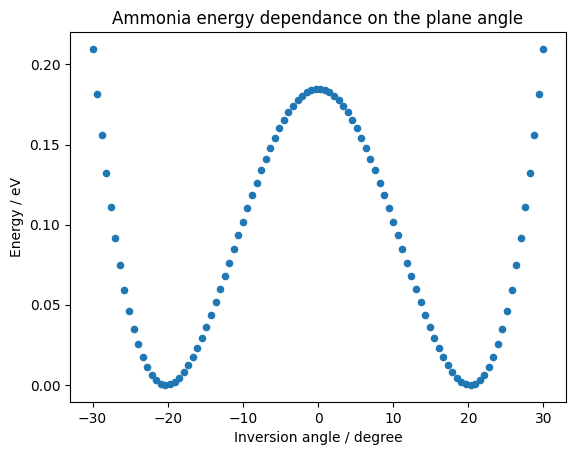

In [ ]:
df.plot.scatter(
    x='angle',
    y='norm_energy',
    title="Ammonia energy dependance on the plane angle",
    xlabel="Inversion angle / degree",
    ylabel="Energy / eV"
    )

In [ ]:
%%capture
%%time
df2 = pd.DataFrame(columns=['angle', 'HNH_angle', 'energy'])
calc = TBLite(method="GFN2-xTB", max_iterations=500, accuracy=0.1, verbosity=0)

for angle in np.linspace(-30, 30, 100):
  atoms, HNH_angle = create_nh3_angle(angle) ##-create system
  BFGS(atoms, trajectory="NH3.traj", logfile="NH3.log").run(fmax=0.05) ##-optimize
  energy = atoms.get_potential_energy() ##-obtain property
  new_row = pd.DataFrame({
      'angle': [angle],
      'HNH_angle': [HNH_angle],
      'energy': [energy],
      })

  df2 = pd.concat([df2, new_row], ignore_index=True)

##-Normalise energy with respect to the lowest energy structure
E_min = df2['energy'].min()
df2['norm_energy'] = df2['energy'] - E_min

<Axes: title={'center': 'Ammonia energy dependance on the plane angle'}, xlabel='Inversion angle / degree', ylabel='Energy / eV'>

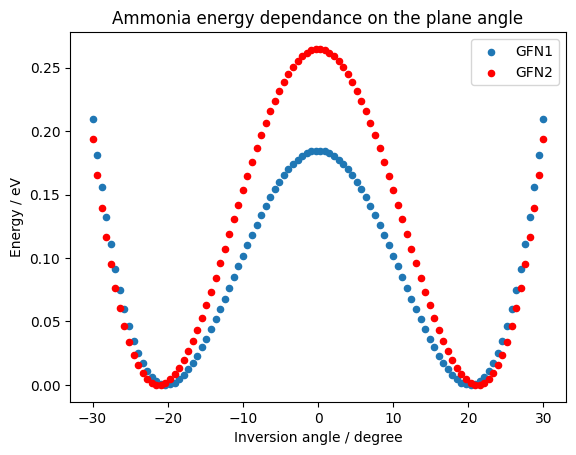

In [ ]:
ax = df.plot.scatter(
    x='angle',
    y='norm_energy',
    title="Ammonia energy dependance on the plane angle",
    xlabel="Inversion angle / degree",
    ylabel="Energy / eV",
    label='GFN1'
    )

df2.plot.scatter(
    x='angle',
    y='norm_energy',
    title="Ammonia energy dependance on the plane angle",
    xlabel="Inversion angle / degree",
    ylabel="Energy / eV",
    color='r',
    label='GFN2',
    ax=ax
    )

For comparison to experiment see https://www.sciencedirect.com/science/article/pii/S001085452100031X

2023 cm$^{-1}$ = 0.25 eV (https://www.colby.edu/chemistry/PChem/Hartree.html)

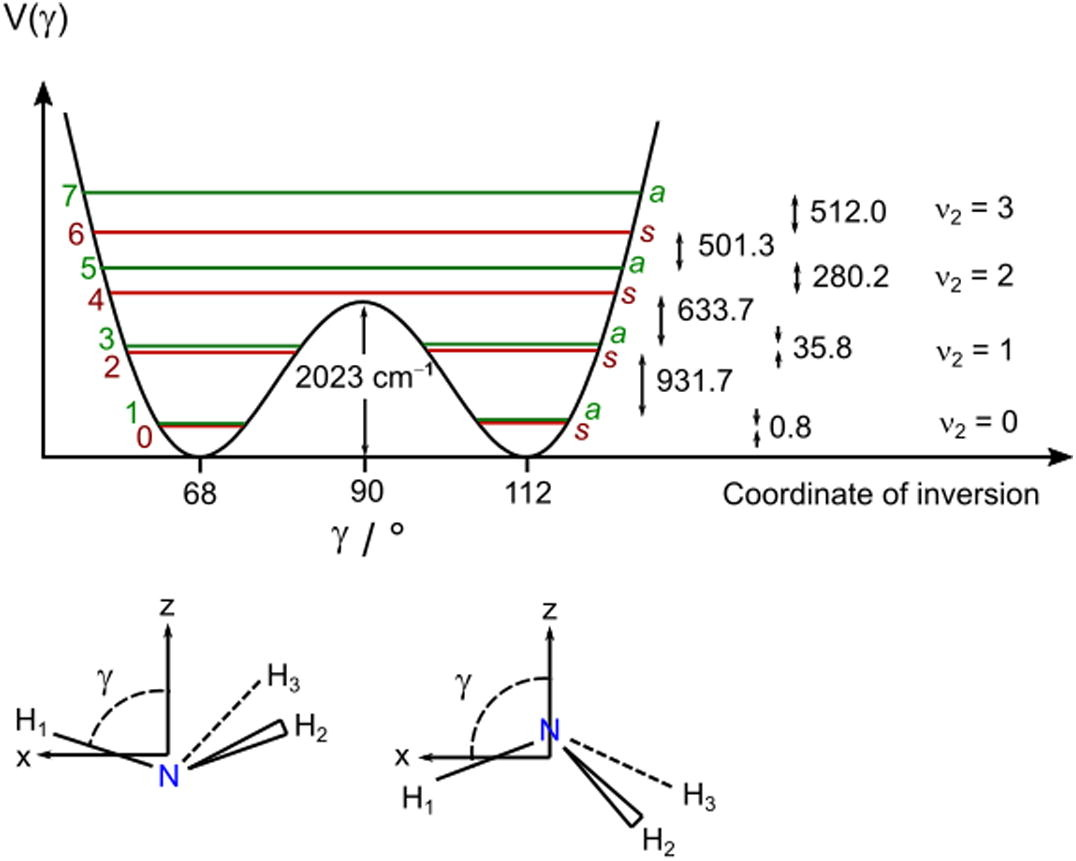

Apply your NH3 logic to a linear Carbon Dioxide molecule. Define a function to bend the O-C-O angle manually and lock it with a constraint.


In [ ]:
def create_co2_angle(angle):
  ##-Convert to radians
  angle = angle*math.pi/180

  ##-Create CO2 with custom angle
  C_O_dist = 1.16
  C = Atoms("C", [(0,0,0)])
  O_1 = Atoms("O", [(0, C_O_dist*math.sin(angle), C_O_dist*math.cos(angle))])
  O_2 = O_1.copy()
  O_2.rotate(180, 'y')
  atoms = C + O_1 + O_2

  ##-Add constraints to angle
  angle_indices1 = [1, 0, 2]
  angle1 = [atoms.get_angle(*angle_indices1), angle_indices1]

  c = FixInternals(angles_deg=[angle1])
  atoms.set_constraint(c)

  atoms.calc = calc

  return atoms, atoms.get_angle(*angle_indices1)

view(create_co2_angle(20)[0], viewer='x3d')

Loop through different angles to forcibly bend the CO2 molecule, calculate the energy for each step, and plot the parabolic curve.


In [ ]:
%%capture

calc = TBLite(method="GFN2-xTB", max_iterations=500, accuracy=1, verbosity=0)

df = pd.DataFrame(columns=['angle', 'energy'])
for angle in np.linspace(-30, 30, 100):
  atoms, _ = create_co2_angle(angle) # create system
  BFGS(atoms, trajectory="CO2.traj", logfile="CO2.log").run(fmax=0.05) # optimize
  energy = atoms.get_potential_energy() # obtain property
  new_row = pd.DataFrame({
        'angle': [angle],
        'energy': [energy],
        })
  df = pd.concat([df, new_row], ignore_index=True)

# Normalise energy with respect to the lowest energy structure
E_min = df['energy'].min()
df['norm_energy'] = df['energy'] - E_min

In [ ]:
df

,angle,energy,norm_energy
0,-30.000000,-277.846039,2.661024
1,-29.393939,-277.978061,2.529002
2,-28.787879,-278.105059,2.402004
3,-28.181818,-278.227211,2.279852
4,-27.575758,-278.344689,2.162374
...,...,...,...
95,27.575758,-278.344689,2.162374
96,28.181818,-278.227211,2.279852
97,28.787879,-278.105059,2.402004
98,29.393939,-277.978061,2.529002


<Axes: title={'center': 'Carbon dioxide energy dependance on the plane angle'}, xlabel='Inversion angle / degree', ylabel='Energy / eV'>

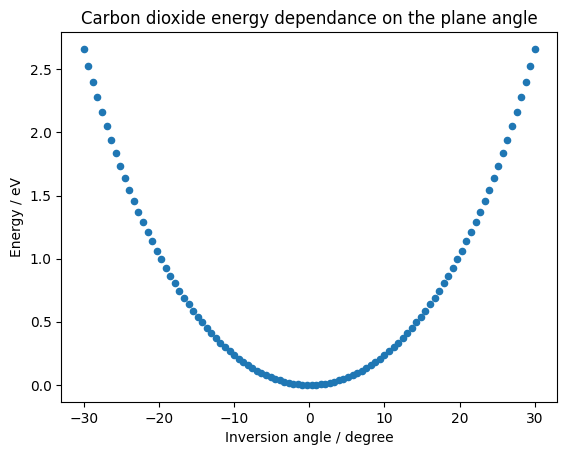

In [ ]:
df.plot.scatter(
    x='angle',
    y='norm_energy',
    title="Carbon dioxide energy dependance on the plane angle",
    xlabel="Inversion angle / degree",
    ylabel="Energy / eV"
)

Fit your calculated CO2 bending curve to a mathematical parabola to extract the force constant. By applying formulas, you will convert this into a vibrational frequency. *(Note: Your result might diverge heavily from experimental data—figuring out why is a great voluntary challenge!)*.


In [ ]:

##-Define quadratic function for fitting
def parabola(x, a, b, c):
  return a * x**2 + b * x + c

##-Constants
eV_to_J = 1.602176634e-19 ##-1 eV in Joules
amu_to_kg = 1.66053906660e-27 ##-atomic mass unit to kg
c_light = 2.99792458e10 ##-speed of light in cm/s
ang_to_rad = np.pi / 180 ##-conversion from degrees to radians

##-Extract data from DataFrame
angles_deg = df['angle'].values
angles_rad = angles_deg * ang_to_rad
energies_eV = df['energy'].values
energies_J = energies_eV * eV_to_J

##-Shift energies so that the minimum is zero
energies_J -= np.min(energies_J)

##-Optionally, select points near the equilibrium angle for the quadratic fit
equilibrium_angle = angles_rad[np.argmin(energies_J)]
fit_range = 0.1  ##-in radians, adjust as needed
mask = np.abs(angles_rad - equilibrium_angle) < fit_range
angles_fit = angles_rad[mask]
energies_fit = energies_J[mask]

##-Fit the parabola to the selected data
params, covariance = curve_fit(parabola, angles_fit, energies_fit)
a, b, c = params

##-Calculate force constant from second derivative (d²E/dθ² = 2a)
force_constant = 2 * a

##-Masses of atoms (kg)
m_O = 15.999 * amu_to_kg
m_C = 12.011 * amu_to_kg

##-Reduced mass for the CO₂ bending mode
reduced_mass = (2 * m_O * m_C) / (2 * m_O + m_C)

##-Calculate vibrational frequency (Hz)
frequency = (1 / (2 * np.pi)) * np.sqrt(force_constant / reduced_mass)

##-Convert frequency to wavenumbers (cm⁻¹)
frequency_wavenumber = frequency / c_light

##-Print results with uncertainties and rounded to two significant digits
print(f"Force constant (J/rad²): {force_constant:.2g}")
print(f"Vibrational frequency (Hz): {frequency:.2g}")
print(f"Vibrational frequency (cm⁻¹): {frequency_wavenumber:.2g}")

Force constant (J/rad²): 2.4e-18
Vibrational frequency (Hz): 2.1e+03
Vibrational frequency (cm⁻¹): 6.9e-08


As an alternative to manual constraints, use ASE's native `Vibrations` module to compute the normal modes of the molecule automatically.

In [ ]:
atoms = Atoms('CO2', positions=[(0, 0, 0), (1.16, 0, 0), (-1.16, 0, 0)])

atoms.center(vacuum=5)

atoms.calc = TBLite(method='GFN2-xTB')

QuasiNewton(atoms).run(fmax=0.05)

# Create vibration calculator
vib = Vibrations(atoms)
vib.run()
vib.summary(method='frederiksen')

# Make trajectory files to visualize normal modes:
for mode in range(9):
  vib.write_mode(mode)

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -10.04381558183  -1.0151445E+01   3.9048095E-01
      2     -10.29417377221  -2.5035819E-01   1.3215617E-01
      3     -10.30591321741  -1.1739445E-02   8.9254251E-02
      4     -10.30636454166  -4.5132426E-04   2.0628631E-02
      5     -10.30732145572  -9.5691406E-04   1.0018776E-03
      6     -10.30732299550  -1.5397799E-06   1.2984363E-04
      7     -10.30732299970  -4.1975987E-09   1.2161238E-05
------------------------------------------------------------

 total:                                   0.006 sec
                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 09:39:41     -280.476545       1.8442
------------------------------------------------------------
  cycle        total energy    energy error   density error
----------------------------------

## Summary

After completing this notebook, you should know:

1. Environment and Python basics, how to run shell commands in Google Colab, create and read files, download data from the web, define Python functions, iterate with loops, and use pandas DataFrames to load, inspect, and plot tabular data.

2. Building molecular structures with ASE, how to construct molecules from built-in collections (g2), fetch structures from PubChem by name, and generate arbitrary geometries from SMILES strings using RDKit. Visualize structures interactively with the x3d viewer and save them to XYZ files.

3. Running simulations with TBLite, how to attach a GFN1-xTB or GFN2-xTB calculator to an ASE Atoms object, perform single-point energy calculations and geometry optimizations with BFGS, and compare the two methods on the same system.

4. Potential energy surface scan, the use ASE constraints (FixInternals) to lock internal coordinates, automate parameter sweeps with loops, store results in DataFrames, and plot energy profiles. The ammonia inversion barrier and the CO2 bending curve are worked examples.

5. Vibrational analysis, fit a parabola to a calculated energy curve to extract a force constant and estimate a vibrational frequency, then cross-check using ASE's built-in Vibrations module for a full normal mode analysis.